In [5]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [6]:
# 2. Load dataset
df = pd.read_csv('data/processed/Defensive_Stats_with_Clusters_2003_2025.csv')

In [7]:
# 3. Calculate win%
df['win_percentage'] = df['w'] / (df['w'] + df['l'])

In [8]:
# 4. Select top 10 defensive teams per season (lower d_rtg is better)
top10_defense = df.sort_values(['season', 'd_rtg']).groupby('season').head(10).reset_index(drop=True)

In [9]:
# 5. Features for clustering (all stats except season, team, abbreviation)
features = top10_defense.columns.drop(['season', 'team', 'abbreviation'])

X = top10_defense[features]

In [10]:
# 6. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

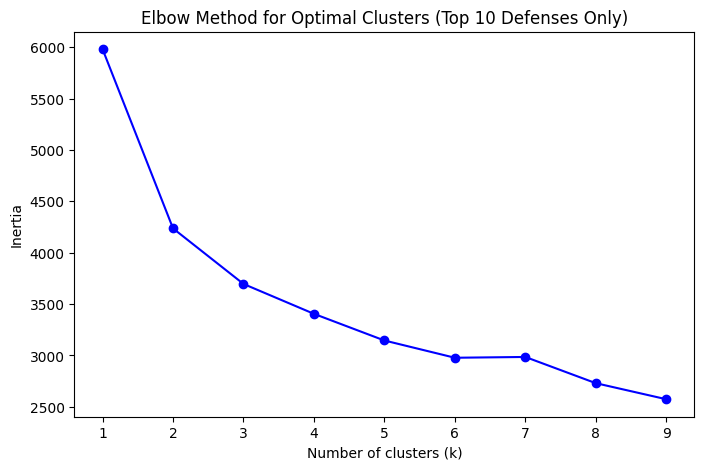

In [11]:
# 7. Elbow method to find optimal clusters
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters (Top 10 Defenses Only)')
plt.show()

In [12]:
# 8. Fit KMeans (start with k=3 or 4 after seeing the elbow)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
top10_defense['elite_def_cluster'] = kmeans.labels_

In [13]:
# 9. Save the elite defensive clustering result
top10_defense.to_csv('data/processed/Elite_Defensive_Clusters_Top10_2003_2025.csv', index=False)

print("✅ Elite Defensive Clusters (Top 10) saved to 'data/processed/Elite_Defensive_Clusters_Top10_2003_2025.csv'")

✅ Elite Defensive Clusters (Top 10) saved to 'data/processed/Elite_Defensive_Clusters_Top10_2003_2025.csv'


/var/folders/k5/1511xdl10db532886zr1dzb40000gn/T/ipykernel_76920/3788390559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='elite_def_cluster', y='season', data=top10_defense, palette='Set2')


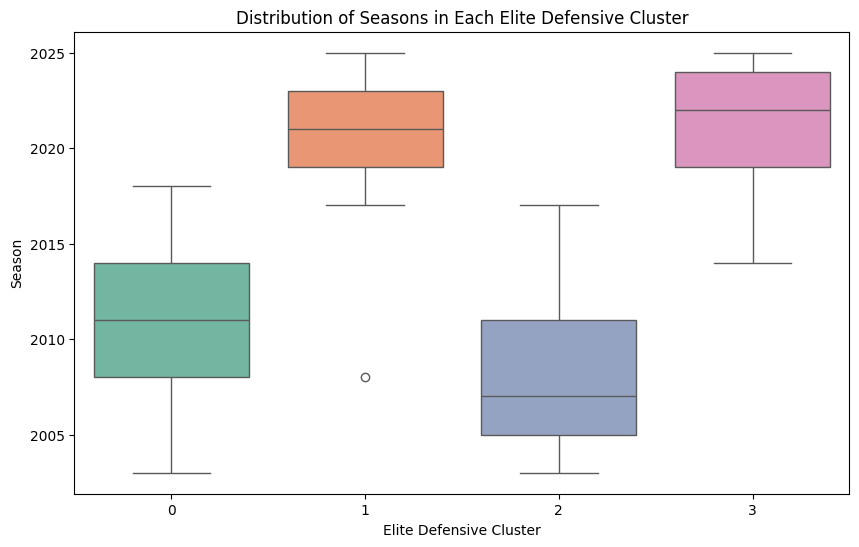

In [14]:
# 10. Boxplot: Distribution of seasons by elite defense cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='elite_def_cluster', y='season', data=top10_defense, palette='Set2')
plt.title('Distribution of Seasons in Each Elite Defensive Cluster')
plt.xlabel('Elite Defensive Cluster')
plt.ylabel('Season')
plt.show()

In [15]:
# 8. Analyze cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
cluster_centers['cluster'] = range(4)
cluster_centers

,age,w,l,d_rtg,pace,opp_e_fg_percent,opp_tov_percent,opp_ft_fga,drb_per_game,stl_per_game,...,opp_x2p_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_orb_per_game,opp_ast_per_game,opp_tov_per_game,opp_pts_per_game,cluster,win_percentage
0,28.157333,55.240000,25.253333,102.117333,91.758667,0.474653,13.541333,0.205160,32.278667,7.626667,...,29.457333,0.464027,16.757333,22.262667,10.904000,20.120000,14.338667,94.400000,0,0.685307
1,26.474603,46.507937,30.301587,108.680952,98.685714,0.520302,13.269841,0.199476,34.404762,8.192063,...,27.695238,0.515889,17.352381,22.547619,10.046032,23.903175,14.836508,107.936508,1,0.607000
2,26.894030,44.641791,36.626866,103.207463,91.159701,0.479015,14.295522,0.241463,30.952239,7.805970,...,28.695522,0.466791,19.068657,25.317910,10.873134,20.241791,15.040299,94.826866,2,0.549755
3,27.184000,46.560000,31.600000,109.688000,97.048000,0.520000,11.896000,0.178240,34.756000,7.088000,...,28.700000,0.515360,15.652000,20.212000,9.924000,23.904000,13.056000,107.116000,3,0.597629


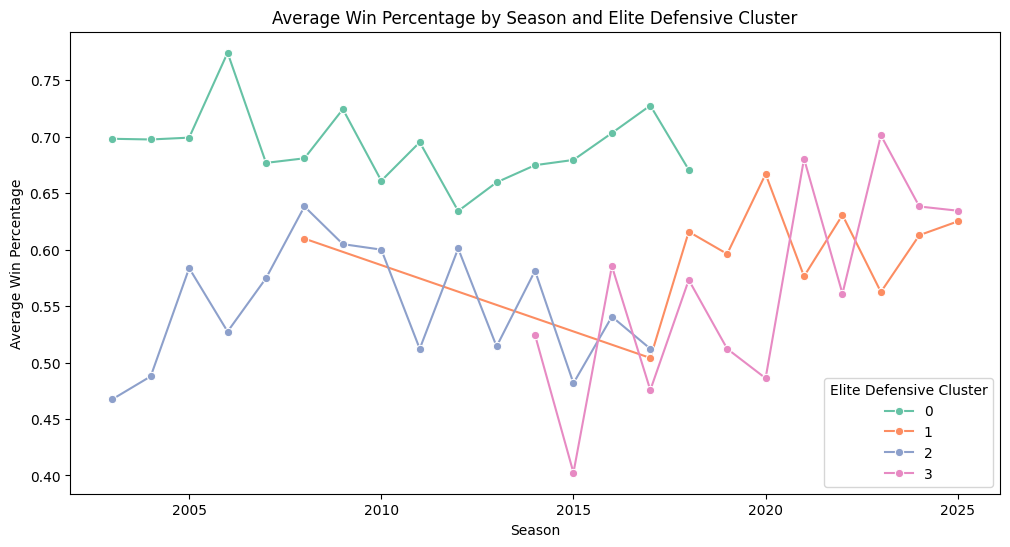

In [16]:
# 11. Visualization: Average win percentage by season and cluster
# Ensure that the previous cells defining `top10_defense` and `win_percentage` are executed before running this cell.

avg_win_by_season_cluster = top10_defense.groupby(['season', 'elite_def_cluster'])['win_percentage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_win_by_season_cluster, x='season', y='win_percentage', hue='elite_def_cluster', palette='Set2', marker='o')
plt.title('Average Win Percentage by Season and Elite Defensive Cluster')
plt.xlabel('Season')
plt.ylabel('Average Win Percentage')
plt.legend(title='Elite Defensive Cluster')
plt.show()